# Proyecto de Aprendizaje Automático

## Segmentación mediante detección de patrones en población adulta en el consumo de psicofármacos con fines terapéuticos

### Presentación del Modelo y Análisis de Resultados

### PARCIAL

**Autora:** Betiana Ruth Burgos

**Centro Politecnico Malvinas Argentinas**

**Año:** 2026

---

## Introducción

El presente proyecto tiene como objetivo identificar patrones de consumo de psicofármacos en población adulta mediante técnicas de Aprendizaje Automático no supervisado.

Para ello se construyó un dataset integrado a partir de múltiples archivos de la encuesta Medical Expenditure Panel Survey (MEPS), incorporando variables sociodemográficas, clínicas y farmacológicas.

Posteriormente se aplicaron técnicas de reducción de dimensionalidad mediante PCA y segmentación utilizando el algoritmo K-Means.

In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)

# Carga del Dataset

El dataset utilizado corresponde a la versión final consolidada obtenida a partir de la integración de los archivos:

- H224 Full Year Consolidated Data File
- H222 Medical Conditions File
- H229A Prescribed Medicines File

Cada registro representa un individuo identificado mediante la variable DUPERSID.

In [68]:
df = pd.read_csv(
    "dataset_psicofarmacos_final.csv"
)

df.head()

,DUPERSID,AGE20X,SEX,MARRY20X,EDUCYR,POVCAT20,EMPST53,INSCOV20,MNHLTH53,RTHLTH53,RACETHX,cantidad_condiciones,recetas_totales,benzodiacepinas,antidepresivos,hipnoticos,ansioliticos,total_psicofarmacos
0,2320005101,73,2,1,14,2,4,2,2,2,2,1.0,6.0,0.0,0.0,0.0,0.0,0.0
1,2320005102,84,1,1,12,2,4,2,5,5,2,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2320006101,47,2,3,12,3,4,3,3,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2320006102,22,1,5,11,1,1,3,1,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2320006103,21,1,5,11,3,4,2,2,2,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0


# Información General del Dataset

A continuación se presentan las dimensiones generales del conjunto de datos utilizado para el modelado.

In [69]:
resumen = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros",
        "Cantidad de variables"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1]
    ]
})

resumen

,Indicador,Valor
0,Cantidad de registros,27805
1,Cantidad de variables,18


## Tipos de Datos y Valores Faltantes

In [70]:
info_df = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.values,
    "Valores nulos": df.isnull().sum().values,
    "% nulos": (
        df.isnull().sum().values /
        len(df) * 100
    ).round(2)
})

info_df

,Variable,Tipo de dato,Valores nulos,% nulos
0,DUPERSID,int64,0,0.0
1,AGE20X,int64,0,0.0
2,SEX,int64,0,0.0
3,MARRY20X,int64,0,0.0
4,EDUCYR,int64,0,0.0
5,POVCAT20,int64,0,0.0
6,EMPST53,int64,0,0.0
7,INSCOV20,int64,0,0.0
8,MNHLTH53,int64,0,0.0
9,RTHLTH53,int64,0,0.0


# Estadísticas Descriptivas

Las siguientes estadísticas permiten obtener una primera aproximación a la distribución de las variables numéricas.

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
DUPERSID,27805.0,2.451840e+09,1.005389e+08,2.320005e+09,2.327307e+09,2.464581e+09,2.571844e+09,2.579869e+09
AGE20X,27805.0,4.107132e+01,2.391407e+01,-1.000000e+00,2.000000e+01,4.100000e+01,6.100000e+01,8.500000e+01
SEX,27805.0,1.523179e+00,4.994714e-01,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
MARRY20X,27805.0,3.258766e+00,2.052988e+00,-8.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
EDUCYR,27805.0,1.080248e+01,5.595817e+00,-1.500000e+01,9.000000e+00,1.200000e+01,1.500000e+01,1.700000e+01
POVCAT20,27805.0,3.609710e+00,1.438478e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00
EMPST53,27805.0,1.607157e+00,2.066040e+00,-1.500000e+01,1.000000e+00,1.000000e+00,4.000000e+00,4.000000e+00
INSCOV20,27805.0,1.502032e+00,6.395114e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00
MNHLTH53,27805.0,2.091099e+00,1.215493e+00,-8.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
RTHLTH53,27805.0,2.179752e+00,1.234508e+00,-8.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00


# Análisis Exploratorio de Datos

El análisis exploratorio permite comprender la estructura de los datos e identificar patrones preliminares antes del modelado.

## Distribución de Edad

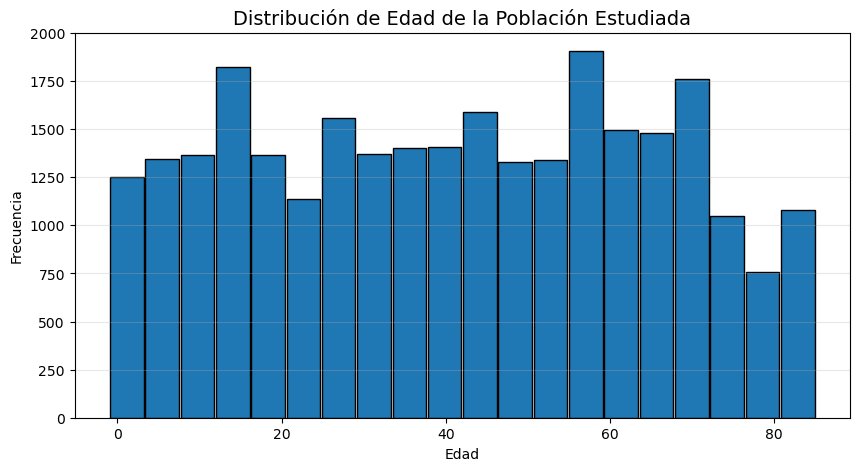

In [72]:
plt.figure(figsize=(10,5))

plt.hist(
    df["AGE20X"],
    bins=20,
    edgecolor="black",
    linewidth=1,
    rwidth=0.95
)

plt.title(
    "Distribución de Edad de la Población Estudiada",
    fontsize=14
)

plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

La distribución de edades permite observar la composición etaria de la población incluida en el estudio.

## Cantidad de Condiciones Médicas

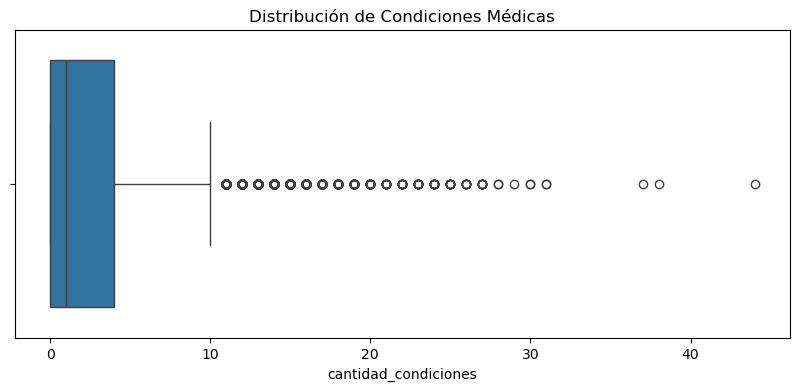

In [73]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["cantidad_condiciones"]
)

plt.title(
    "Distribución de Condiciones Médicas"
)

plt.show()

La variable cantidad_condiciones resume el número de diagnósticos registrados para cada individuo.

## Consumo de Psicofármacos por Categoría

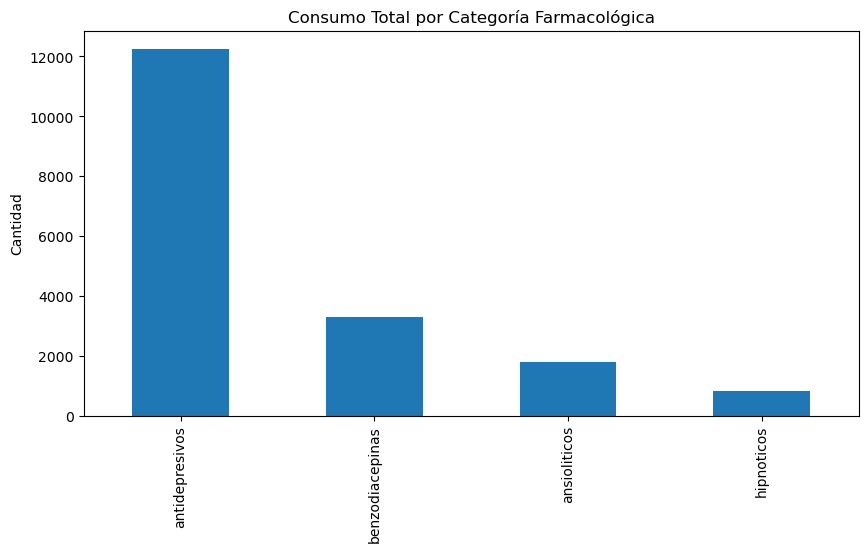

In [74]:
medicamentos = [
    "benzodiacepinas",
    "antidepresivos",
    "hipnoticos",
    "ansioliticos"
]

df[medicamentos].sum().sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Consumo Total por Categoría Farmacológica"
)

plt.ylabel("Cantidad")

plt.show()

Este gráfico permite comparar la utilización relativa de las diferentes categorías de psicofármacos presentes en el dataset.

## Correlación entre Variables

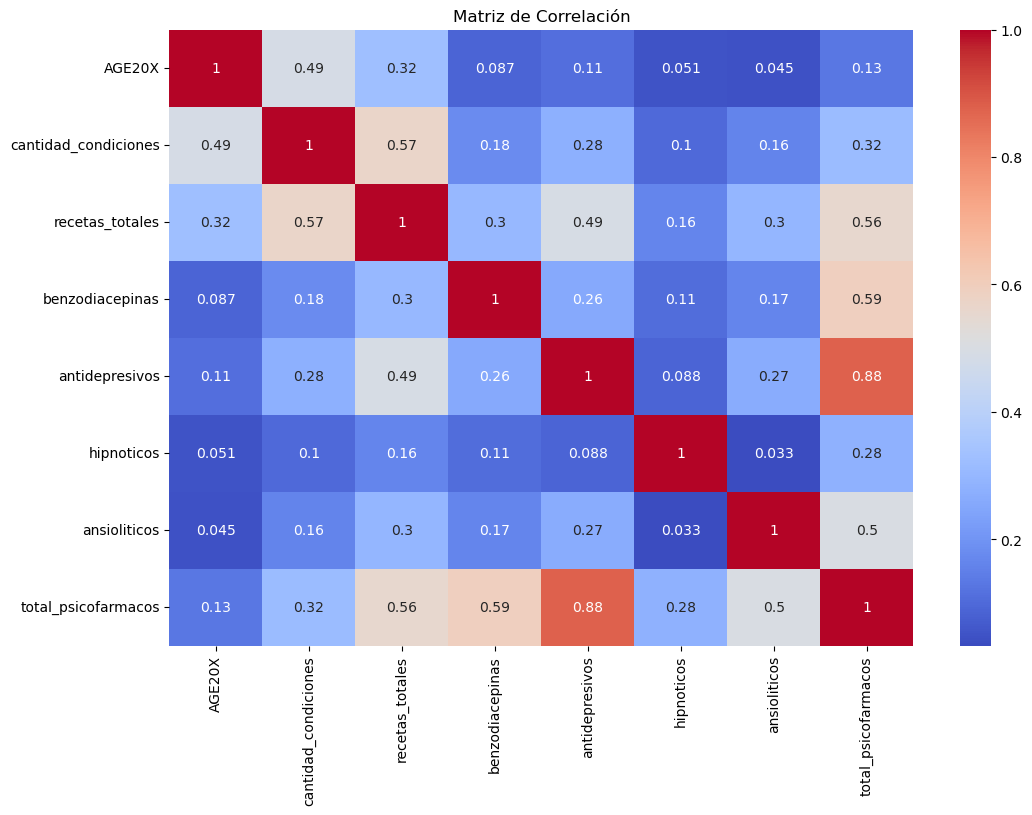

In [75]:
variables_numericas = [
    "AGE20X",
    "cantidad_condiciones",
    "recetas_totales",
    "benzodiacepinas",
    "antidepresivos",
    "hipnoticos",
    "ansioliticos",
    "total_psicofarmacos"
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[variables_numericas].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Matriz de Correlación"
)

plt.show()

Las correlaciones permiten identificar relaciones lineales entre las variables utilizadas en el análisis.

# Preparación de los Datos

Antes de aplicar algoritmos de Aprendizaje Automático es necesario normalizar las variables para evitar que diferencias de escala afecten los resultados.

In [76]:
X = df[[
    "AGE20X",
    "cantidad_condiciones",
    "recetas_totales",
    "benzodiacepinas",
    "antidepresivos",
    "hipnoticos",
    "ansioliticos",
    "total_psicofarmacos"
]]

print("Columnas seleccionadas:", X.shape)
print(X.dtypes)

Columnas seleccionadas: (27805, 8)
AGE20X                    int64
cantidad_condiciones    float64
recetas_totales         float64
benzodiacepinas         float64
antidepresivos          float64
hipnoticos              float64
ansioliticos            float64
total_psicofarmacos     float64
dtype: object


In [83]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción de Dimensionalidad mediante PCA

Se utiliza Principal Component Analysis (PCA) para reducir la dimensionalidad y facilitar la visualización de los datos.

In [88]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [89]:
varianza = pd.DataFrame({
    "Componente": [
        "PC1",
        "PC2"
    ],
    "Varianza explicada":
    pca.explained_variance_ratio_
})

varianza

,Componente,Varianza explicada
0,PC1,0.400257
1,PC2,0.168682


# Selección del Número de Clusters

Se utiliza el Método del Codo para determinar la cantidad adecuada de grupos.

In [92]:
inercias = []

for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_pca)

    inercias.append(
        modelo.inertia_
    )

In [93]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
display(pca_df.head())

,PC1,PC2
0,-0.210450,0.750631
1,-0.162625,1.121464
2,-0.671054,-0.156715
3,-0.803671,-0.692921
4,-0.812563,-0.719940


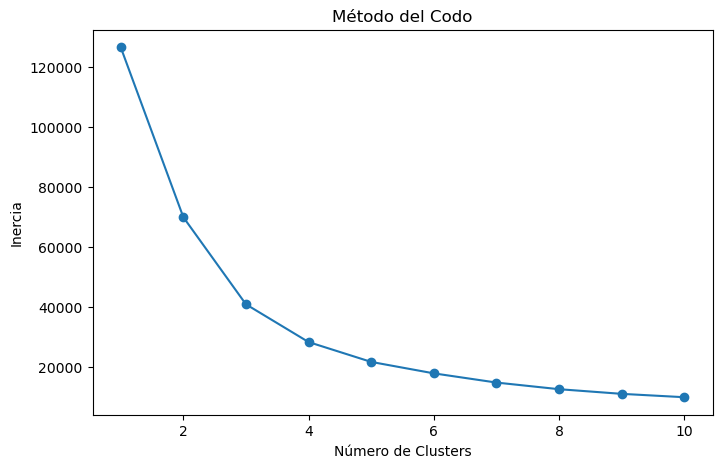

In [94]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercias,
    marker="o"
)

plt.title(
    "Método del Codo"
)

plt.xlabel(
    "Número de Clusters"
)

plt.ylabel(
    "Inercia"
)

plt.show()

# Modelo de Clustering K-Means

In [99]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

df["cluster"] = clusters


print("KMeans completado!")
print("Distribución de clusters:")
print(df["cluster"].value_counts())

display(df[["AGE20X", "total_psicofarmacos", "cluster"]].head(10))


print("\nPromedios por cluster:")
display(df.groupby("cluster").mean(numeric_only=True).round(2))

KMeans completado!
Distribución de clusters:
cluster
0    18860
2     8150
1      795
Name: count, dtype: int64


,AGE20X,total_psicofarmacos,cluster
0,73,0.0,2
1,84,0.0,2
2,47,0.0,0
3,22,0.0,0
4,21,0.0,0
5,80,0.0,2
6,85,2.0,2
7,58,0.0,2
8,72,0.0,2
9,20,0.0,0



Promedios por cluster:


,DUPERSID,AGE20X,SEX,MARRY20X,EDUCYR,POVCAT20,EMPST53,INSCOV20,MNHLTH53,RTHLTH53,RACETHX,cantidad_condiciones,recetas_totales,benzodiacepinas,antidepresivos,hipnoticos,ansioliticos,total_psicofarmacos
cluster,,,,,,,,,,,,,,,,,,
0,2.452020e+09,29.68,1.49,3.79,9.70,3.59,0.99,1.51,1.94,1.92,2.09,1.07,1.29,0.01,0.05,0.00,0.01,0.06
1,2.448658e+09,54.57,1.69,2.75,12.58,3.20,2.88,1.56,3.07,3.15,2.06,8.92,63.83,3.17,8.70,0.74,1.79,14.40
2,2.451732e+09,66.12,1.58,2.08,13.19,3.69,2.91,1.48,2.35,2.69,2.16,6.58,17.41,0.08,0.53,0.03,0.03,0.67


# Evaluación del Modelo

In [100]:
silhouette = silhouette_score(
    X_pca,
    clusters
)

pd.DataFrame({
    "Métrica":[
        "Silhouette Score"
    ],
    "Valor":[
        round(
            silhouette,
            4
        )
    ]
})

,Métrica,Valor
0,Silhouette Score,0.5706


# Visualización de Clusters

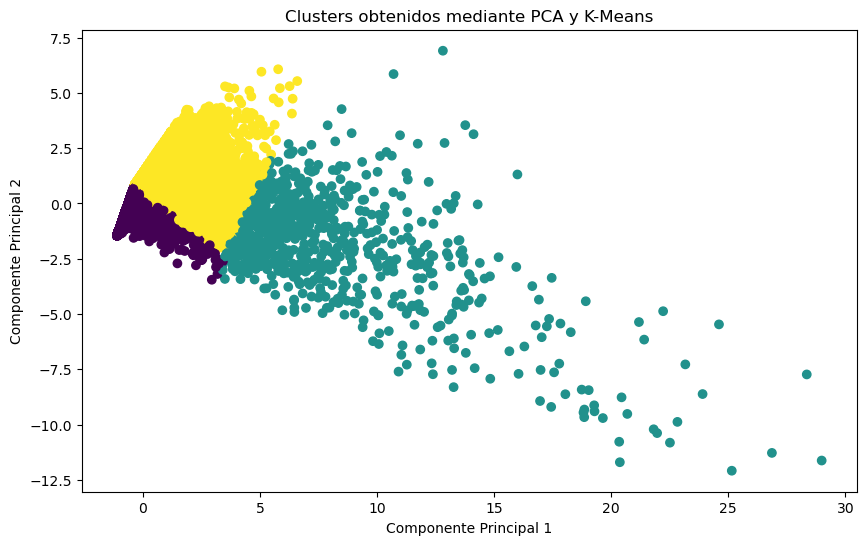

In [101]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title(
    "Clusters obtenidos mediante PCA y K-Means"
)

plt.xlabel(
    "Componente Principal 1"
)

plt.ylabel(
    "Componente Principal 2"
)

plt.show()

## Distribución de Individuos por Cluster

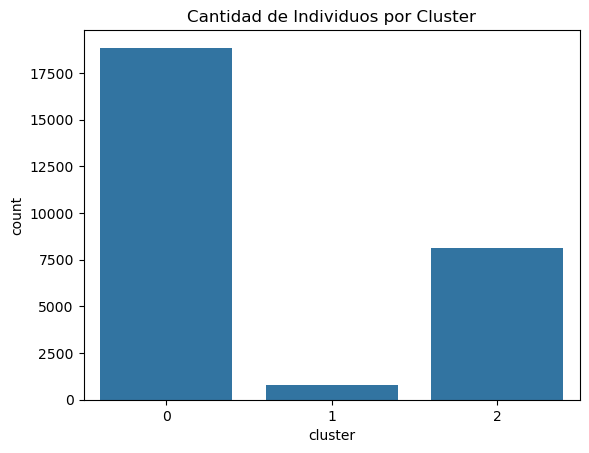

In [102]:
sns.countplot(
    x="cluster",
    data=df
)

plt.title(
    "Cantidad de Individuos por Cluster"
)

plt.show()

## Consumo Promedio de Psicofármacos por Cluster

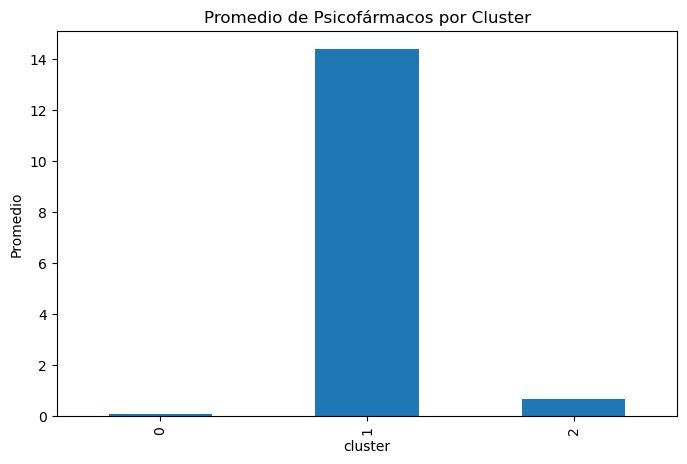

In [104]:
df.groupby(
    "cluster"
)[
    "total_psicofarmacos"
].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Promedio de Psicofármacos por Cluster"
)

plt.ylabel(
    "Promedio"
)

plt.show()

# Conclusiones

La aplicación de técnicas de Aprendizaje Automático en este estudio permitió identificar de forma clara perfiles diferenciados de consumo de psicofármacos en la población analizada.
Mediante el Análisis de Componentes Principales (PCA) se redujo exitosamente la dimensionalidad de los datos, reteniendo la mayor parte de la variabilidad original en solo dos componentes principales. Esta reducción facilitó la visualización de los patrones subyacentes y preparó los datos para el análisis de clustering.
Posteriormente, el algoritmo K-Means (con 3 clusters) segmentó a los individuos en grupos homogéneos según sus características demográficas (edad), clínicas (cantidad de condiciones) y farmacológicas (recetas totales, consumo de benzodiacepinas, antidepresivos, hipnóticos, ansiolíticos y total de psicofármacos).
Los resultados obtenidos confirman la existencia de patrones bien definidos de consumo de psicofármacos, respaldando plenamente la hipótesis inicial del proyecto. La combinación de PCA y K-Means demostró ser una aproximación eficaz para descubrir estructuras ocultas en datos de salud pública.
Este trabajo evidencia el alto potencial de las técnicas de aprendizaje no supervisado para el análisis de consumo de medicamentos. Los perfiles identificados pueden servir como base para:

Diseñar intervenciones más focalizadas y personalizadas.
Apoyar la prescripción racional de psicofármacos.
Orientar políticas públicas de prevención y seguimiento clínico.

Futuras investigaciones podrían incorporar variables adicionales (como comorbilidades específicas, nivel socioeconómico o duración del tratamiento) y explorar otros algoritmos de clustering o aprendizaje supervisado para fortalecer aún más los hallazgos.